In [1]:
import numpy as np

### Let's try it with coqui.tts
- I couldn't create a prper Hungarian prosody, if I put a "?", for example at the end of a sentence, for a question, the output has the same prosody as without it
- maybe there isn't much Hungarian training data
 

In [ ]:
# Import the TTS library
from TTS.api import TTS

from IPython.display import Audio

In [ ]:
# Initialize the TTS model
from TTS.utils.manage import ModelManager

manager = ModelManager()
manager.list_models()

In [ ]:
# Load the Hungarian model
hun_model = "tts_models/hu/css10/vits"

# Instantiate the TTS object with the Hungarian model
tts = TTS(model_name=hun_model, progress_bar=True, gpu=False)

# Generate speech
tts.tts_to_file(text="Mit csináltok?", file_path="question1.wav", speed=0.9,
                Pitch=0.9, Volume=1.0, SampleRate=22050, SpeakerID=0)

print("Speech saved as question1.wav!")


Speech saved as question1.wav!


In [ ]:
# Play the generated audio file
Audio("question1.wav")

In [27]:
text = "Hány testvéred van!"
# Generate speech for the new text

tts.tts_to_file(text=text, file_path="testver.wav", use_deepvoice=True)

Audio("testver.wav")



### Let's try it with pyworlds

In [3]:
# Import necessary libraries for audio processing
import soundfile as sf
# import pyworld as pw
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import librosa as lr
from IPython.display import Audio

In [ ]:
# Import audio
filename = "data/Herpai_Julia_eso_24.wav"

# Using soundfile to read the audio file
x, fs = sf.read(filename)

In [9]:
# Calculate SNR
signal, sr = lr.load(filename, sr=fs)
# ez valami miatt nem működik
"""noise_estimate = lr.effects.harmonic(signal)

# Calculate signal and noise power
signal_power = np.mean(signal**2)
noise_power = np.mean(noise_estimate**2)

# Compute the SNR in dB
snr_db = 10 * np.log10(signal_power / noise_power)
print(f"SNR (dB): {snr_db}")"""

'noise_estimate = lr.effects.harmonic(signal)\n\n# Calculate signal and noise power\nsignal_power = np.mean(signal**2)\nnoise_power = np.mean(noise_estimate**2)\n\n# Compute the SNR in dB\nsnr_db = 10 * np.log10(signal_power / noise_power)\nprint(f"SNR (dB): {snr_db}")'

In [4]:
# Extract speech features with wav2world
f0_w2w, sp_w2w, ap_w2w = pw.wav2world(x, fs)
# Extract speech features with dio
f0_dio, t = pw.dio(x, fs)
# Extract speech features with harvest
f0_harv, t = pw.harvest(x, fs)
# Extract smoothed spectrogram with cheaptrick
sp_ch = pw.cheaptrick(x, f0_dio, t, fs)
#Extract aperiodicity with d4c
ap_d4c = pw.d4c(x, f0_dio, t, fs)
f0_stone= pw.stonemask(x, f0_dio, t, fs)



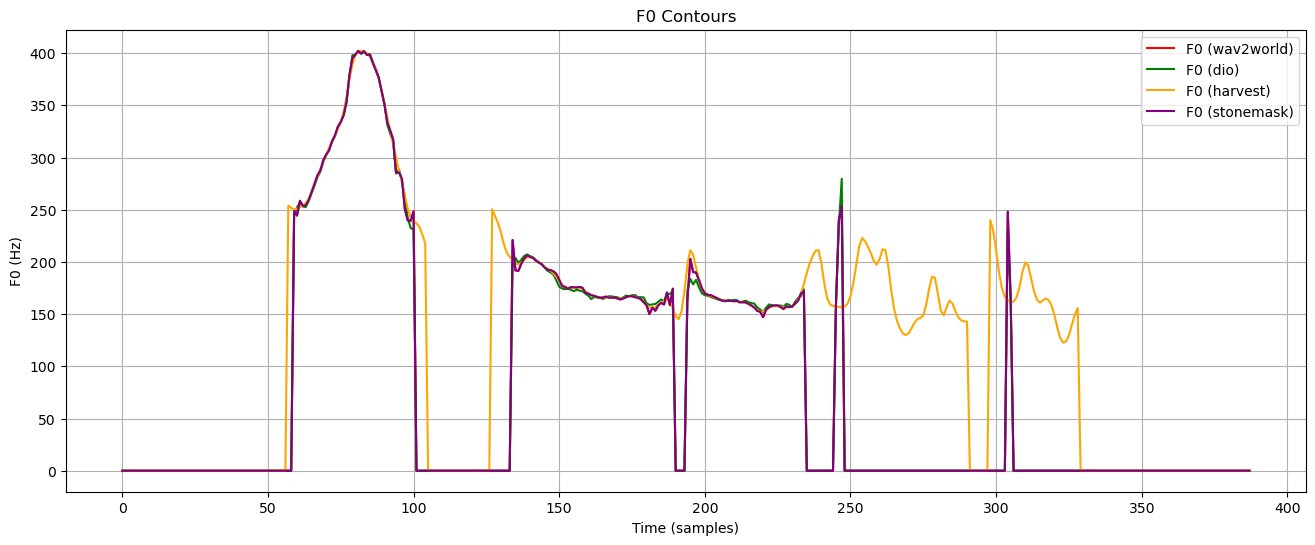

In [5]:
# Visualize f0s from different methods
plt.figure(figsize=(16, 6))
# plt.plot(x, color='blue', label='Original signal')
plt.plot(f0_w2w, color='red', label='F0 (wav2world)')
plt.plot(f0_dio, color='green', label='F0 (dio)')
plt.plot(f0_harv, color='orange', label='F0 (harvest)')
plt.plot(f0_stone, color='purple', label='F0 (stonemask)')
plt.title('F0 Contours')
plt.xlabel('Time (samples)')
plt.ylabel('F0 (Hz)')
plt.legend()
plt.grid()
plt.show() 

In [ ]:
# Using the harvest method for resynthesizing the sentence
# f0_harv already given from previous cells
# Extract spectrogram with cheaptrick
sp_ch = pw.cheaptrick(x, f0_harv, t, fs)
# Extract aperiodicity with d4c
ap_d4c = pw.d4c(x, f0_harv, t, fs)
# Resynthesize the signal using the extracted features
x_re = pw.synthesize(f0_harv, sp_ch, ap_d4c, fs)

# Save the resynth audio
sf.write("synthesized_sentence.wav", x_re, fs)

In [ ]:
#Play the new audio
Audio("synthesized_sentence.wav")

In [13]:
# Play the original audio
Audio(signal, rate=fs)

### Most próbáljuk meg a kvantizált MIDI-t felhasználni a szintetizáláshoz

In [ ]:
# Convert midi note to frequency (f0)
def midi_to_hz(midi):
    return 440.0 * 2 ** ((midi - 69) / 12)

# Function to convert a MIDI file to a pitch contour
def midi_to_pitch_contour(midi_file, fs):
    midi_data = mido.MidiFile(midi_file)
    
    time_steps = []
    f0_values = []
    
    current_time = 0
    for msg in midi_data.play():
        if msg.type == 'note_on':  # Note on event
            midi_note = msg.note
            # Convert MIDI note to frequency (f0)
            f0 = midi_to_hz(midi_note)
            time_steps.append(current_time)
            f0_values.append(f0)
        
        current_time += msg.time  # Update time step for each event
    
    # Make sure f0_values and time_steps match up in terms of length
    # If the note duration is very short, you may need to adjust time_steps accordingly

    # Convert time_steps to match the sample rate
    t = np.array(time_steps) / float(fs)
    f0 = np.array(f0_values)

    return f0, t

#### Because of the quantization it is easier to convert it into MIDI, then convert back to Hz for the synthesis